# House Price Prediction System

## Project Goal
Build a Machine Learning model that predicts house prices based on property features.

## Workflow
1. Data Exploration
2. Data Cleaning
3. Feature Engineering
4. Model Training
5. Model Evaluation
6. Model Selection
7. Model Saving

## Section 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 2: Load Dataset

In [2]:
df = pd.read_csv("../../data/raw.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (300, 8)

First 5 rows:


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [3]:
print("Data Types:")
df.dtypes

Data Types:


Property_ID      object
Area              int64
Bedrooms          int64
Bathrooms         int64
Age               int64
Location         object
Property_Type    object
Price             int64
dtype: object

In [4]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


## Section 3: Exploratory Data Analysis

In [5]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Missing Values:
Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

Duplicate Rows: 0


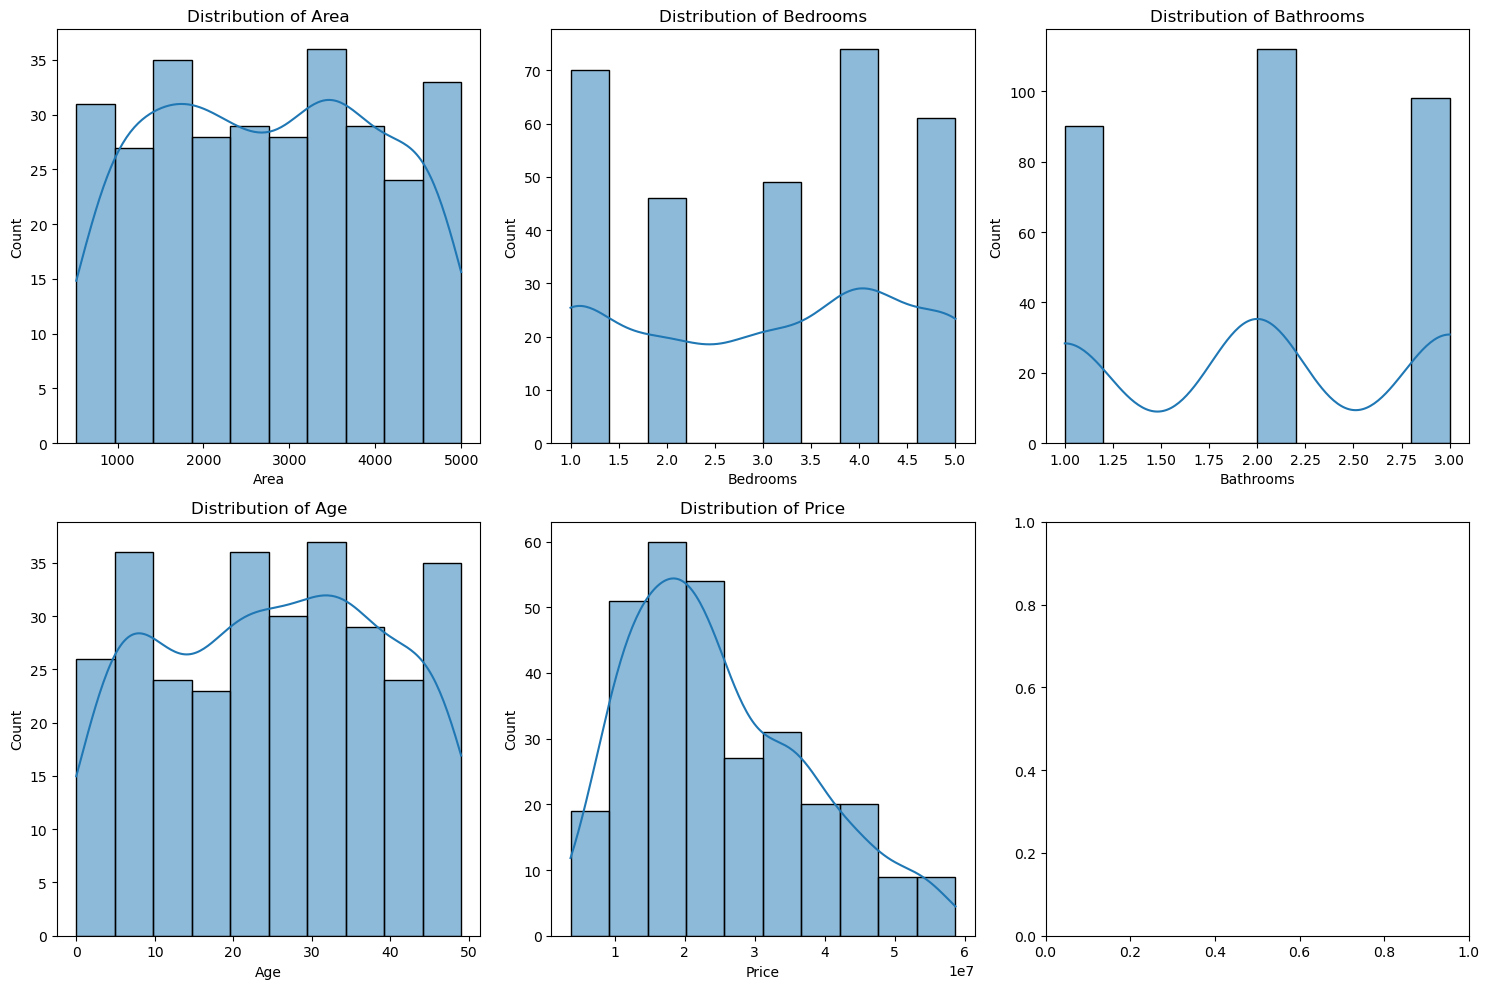

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numeric_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price']
for i, col in enumerate(numeric_cols):
    ax = axes[i // 3, i % 3]
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

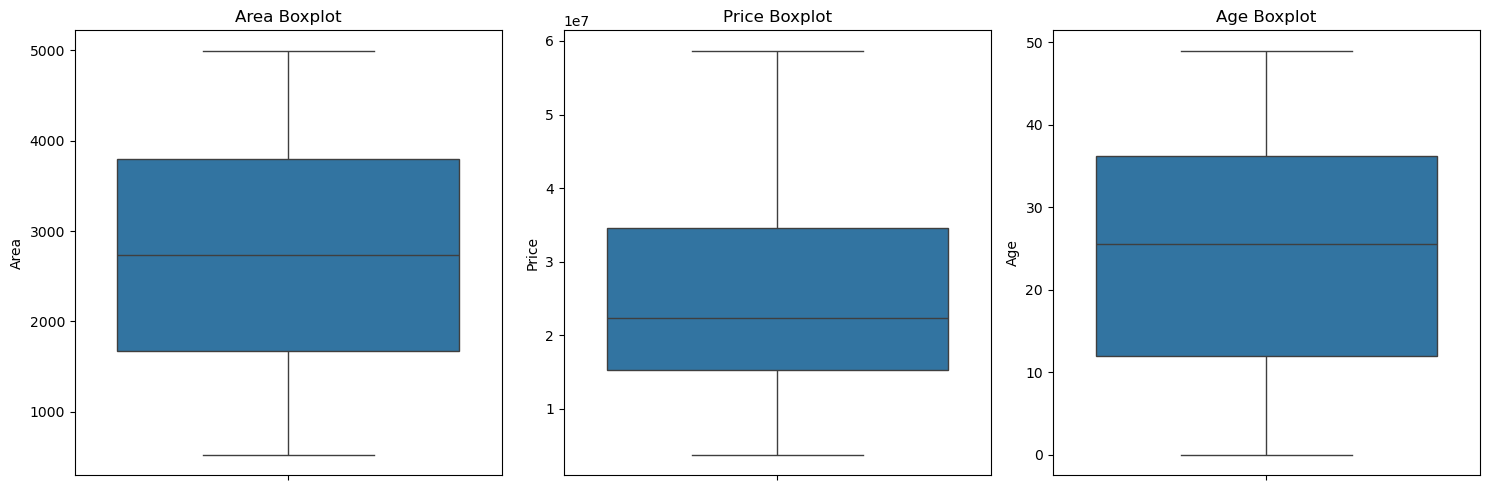

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df['Area'], ax=axes[0])
axes[0].set_title('Area Boxplot')
sns.boxplot(y=df['Price'], ax=axes[1])
axes[1].set_title('Price Boxplot')
sns.boxplot(y=df['Age'], ax=axes[2])
axes[2].set_title('Age Boxplot')
plt.tight_layout()
plt.show()

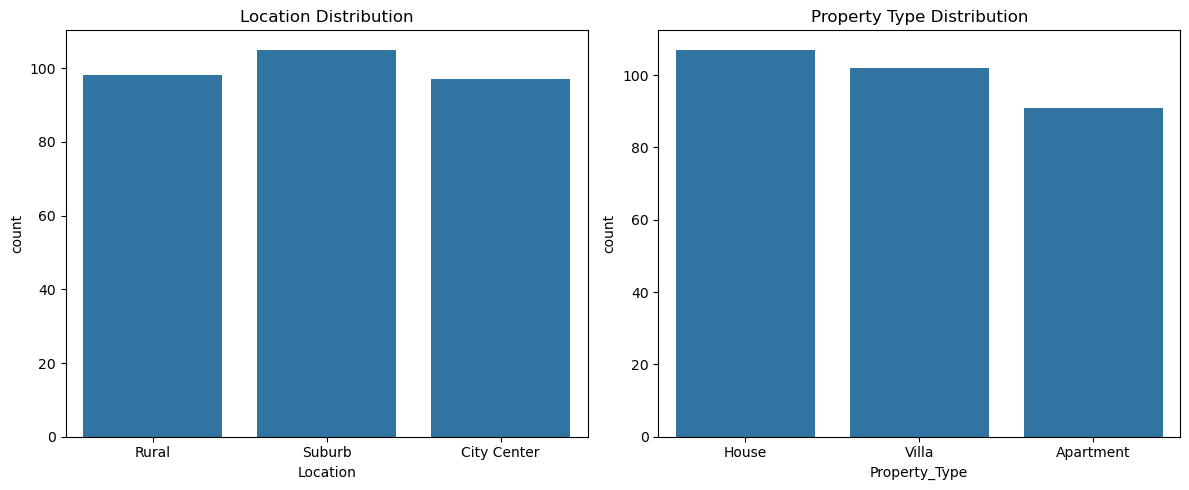

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='Location', ax=axes[0])
axes[0].set_title('Location Distribution')
sns.countplot(data=df, x='Property_Type', ax=axes[1])
axes[1].set_title('Property Type Distribution')
plt.tight_layout()
plt.show()

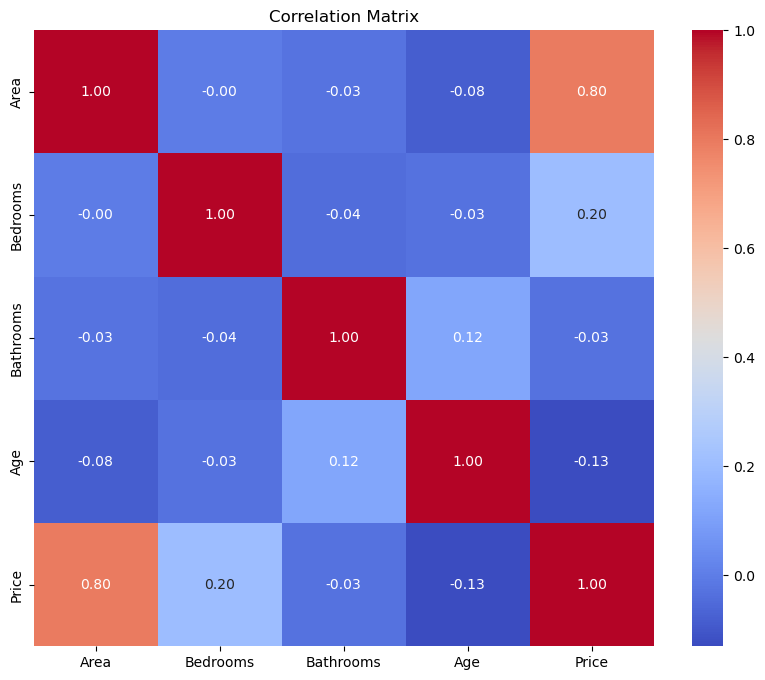

In [9]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [10]:
# Outlier Detection using IQR
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

Area: 0 outliers detected
Bedrooms: 0 outliers detected
Bathrooms: 0 outliers detected
Age: 0 outliers detected
Price: 0 outliers detected


## Section 4: Data Cleaning

In [11]:
df_clean = df.copy()
if 'Property_ID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Property_ID'])
df_clean = df_clean.drop_duplicates()
print(f"After dropping duplicates: {df_clean.shape}")

After dropping duplicates: (300, 7)


In [12]:
# Handle outliers using IQR capping
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower, upper)
print(f"After outlier capping: {df_clean.shape}")
print(f"\nCleaned data statistics:")
df_clean.describe()

After outlier capping: (300, 7)

Cleaned data statistics:


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


In [13]:
# Save cleaned dataset
df_clean.to_csv("../data/processed/cleaned_data.csv", index=False)
print("Cleaned data saved to ../data/processed/cleaned_data.csv")

Cleaned data saved to ../data/processed/cleaned_data.csv


## Section 5: Feature Engineering

In [14]:
df_fe = df_clean.copy()
# Create additional features
df_fe['Area_per_Bedroom'] = df_fe['Area'] / (df_fe['Bedrooms'] + 1)
df_fe['Area_per_Bathroom'] = df_fe['Area'] / (df_fe['Bathrooms'] + 1)
print(f"New features added. Shape: {df_fe.shape}")
df_fe.head()

New features added. Shape: (300, 9)


,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price,Area_per_Bedroom,Area_per_Bathroom
0,3712,4,3,36,Rural,House,22260000,742.4,928.000000
1,1591,4,1,35,Suburb,House,16057500,318.2,795.500000
2,1646,4,3,20,Rural,Villa,12730000,329.2,411.500000
3,4814,1,2,13,City Center,Villa,50840000,2407.0,1604.666667
4,800,4,2,38,Suburb,Apartment,10650000,160.0,266.666667


## Section 6: Train/Test Split

In [16]:
X = df_fe.drop(columns=['Price'])
y = df_fe['Price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=18
)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (240, 8)
Test set: (60, 8)


## Section 7: Model Training

In [17]:
# Define preprocessing pipeline
numeric_features = ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Area_per_Bedroom', 'Area_per_Bathroom']
categorical_features = ['Location', 'Property_Type']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")

Processed training shape: (240, 10)
Processed test shape: (60, 10)


In [18]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
y_pred_lr = lr.predict(X_test_processed)
print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [19]:
# Model 2: Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_processed, y_train)
y_pred_rf = rf.predict(X_test_processed)
print("Random Forest trained successfully!")

Random Forest trained successfully!


In [20]:
# Model 3: Gradient Boosting Regressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_processed, y_train)
y_pred_gb = gb.predict(X_test_processed)
print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


## Section 8: Model Evaluation

In [21]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae, 2), 'MSE': round(mse, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)}

results = [
    evaluate_model('Linear Regression', y_test, y_pred_lr),
    evaluate_model('Random Forest', y_test, y_pred_rf),
    evaluate_model('Gradient Boosting', y_test, y_pred_gb),
]

results_df = pd.DataFrame(results)
print("\n=== Model Performance Comparison ===\n")
print(results_df.to_string(index=False))


=== Model Performance Comparison ===

            Model        MAE          MSE       RMSE     R2
Linear Regression 2363205.33 9.177370e+12 3029417.43 0.9467
    Random Forest 1558418.33 4.087102e+12 2021658.27 0.9762
Gradient Boosting 1233884.14 2.691259e+12 1640505.85 0.9844


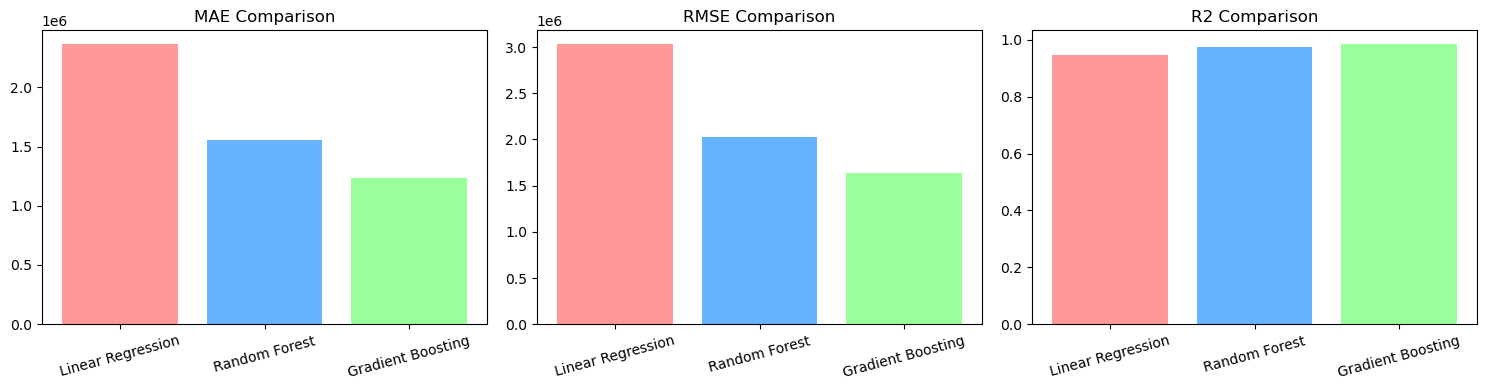

In [22]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['#ff9999', '#66b3ff', '#99ff99']
for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric], color=colors)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Section 9: Select Best Model

In [23]:
best_idx = results_df['R2'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model_obj = [lr, rf, gb][best_idx]
print(f"🏆 Best Model: {best_model_name}")
print(f"R² Score: {results_df.loc[best_idx, 'R2']}")
print(f"RMSE: {results_df.loc[best_idx, 'RMSE']}")

🏆 Best Model: Gradient Boosting
R² Score: 0.9844
RMSE: 1640505.85


## Section 10: Feature Importance

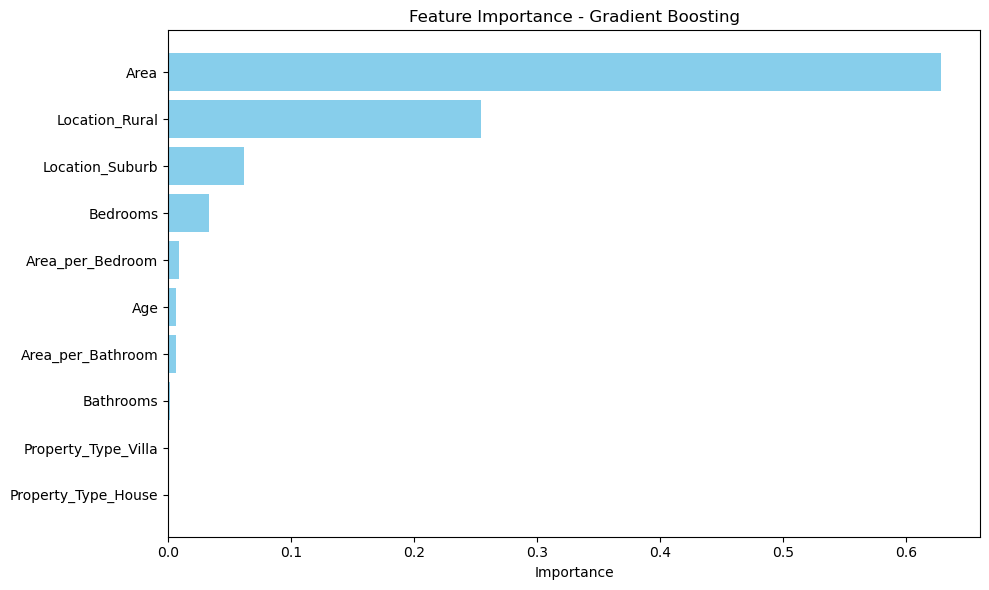


=== Feature Importance ===
Area: 0.6286
Location_Rural: 0.2541
Location_Suburb: 0.0613
Bedrooms: 0.0330
Area_per_Bedroom: 0.0090
Age: 0.0066
Area_per_Bathroom: 0.0060
Bathrooms: 0.0014
Property_Type_Villa: 0.0001
Property_Type_House: 0.0000


In [24]:
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    # Get feature names after transformation
    cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_features = list(numeric_features) + list(cat_features)
    
    importances = best_model_obj.feature_importances_
    importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
    importance_df = importance_df.sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print("\n=== Feature Importance ===")
    for _, row in importance_df.sort_values('Importance', ascending=False).iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")
elif best_model_name == 'Linear Regression':
    cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_features = list(numeric_features) + list(cat_features)
    coefficients = pd.DataFrame({'Feature': all_features, 'Coefficient': best_model_obj.coef_})
    coefficients = coefficients.sort_values('Coefficient', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='lightcoral')
    plt.title('Feature Coefficients - Linear Regression')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()

In [25]:
# Business Insights
print("\n=== Business Insights ===\n")
print("1. Area contributes most significantly to house price.")
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    top_features = importance_df.sort_values('Importance', ascending=False).head(3)
    for _, row in top_features.iterrows():
        print(f"   - {row['Feature']} is a key price driver (importance: {row['Importance']:.4f})")
print("2. Location significantly impacts property value.")
print("3. Property type and size are crucial price determinants.")


=== Business Insights ===

1. Area contributes most significantly to house price.
   - Area is a key price driver (importance: 0.6286)
   - Location_Rural is a key price driver (importance: 0.2541)
   - Location_Suburb is a key price driver (importance: 0.0613)
2. Location significantly impacts property value.
3. Property type and size are crucial price determinants.


## Section 11: Save Best Model

In [26]:
# Save the best model along with its preprocessor
model_artifact = {
    'model': best_model_obj,
    'preprocessor': preprocessor
}
joblib.dump(model_artifact, '../models/best_model.pkl')
print(f"Best model ({best_model_name}) saved to ../models/best_model.pkl")

# Verify the saved model
loaded = joblib.load('../models/best_model.pkl')
loaded_model = loaded['model']
loaded_preprocessor = loaded['preprocessor']
print(f"Verified: Model type = {type(loaded_model).__name__}")
print(f"Verified: Preprocessor type = {type(loaded_preprocessor).__name__}")

Best model (Gradient Boosting) saved to ../models/best_model.pkl
Verified: Model type = GradientBoostingRegressor
Verified: Preprocessor type = ColumnTransformer


In [ ]:
# Quick prediction test
sample = X_test.iloc[[0]]
sample_processed = preprocessor.transform(sample)
pred = best_model_obj.predict(sample_processed)[0]
actual = y_test.iloc[0]
print(f"\nSample Prediction Test:")
print(f"Actual Price: {actual:,.2f}")
print(f"Predicted Price: {pred:,.2f}")
print(f"Difference: {abs(actual - pred):,.2f}")


Sample Prediction Test:
Actual Price: 18,085,000.00
Predicted Price: 18,018,234.26
Difference: 66,765.74


: 

## Summary

- **Dataset**: House price data with 300 records, 8 columns
- **Models Trained**: Linear Regression, Random Forest, Gradient Boosting
- **Best Model**: Selected based on highest R² score and lowest error metrics
- **Saved Model**: `../models/best_model.pkl` with preprocessor pipeline
- **Next Steps**: Deploy via FastAPI backend with HTML/CSS/JS frontend